# Notebook 04 — Conflicting Metadata & Field-Level Data Quality

## Objective

Extend notebooks 01–03 with the two remaining report pillars:

1. **Conflicting metadata** between OpenAlex, Crossref, and Local on shared DOIs
2. **Field-level data-quality statistics** (completeness, conflict rate, enrichment fill, DQ score)

## Inputs

- OpenAlex: `data/raw/open-alex/open_alex.csv`
- Crossref: `data/processed/crossref_clean_2016_2026_enriched.csv`
- Local: `data/raw/open-alex/repositories_combined.csv`
- Prior outputs under `outputs/notebook02` and `outputs/notebook03` (optional joins)

## Outputs

`./outputs/notebook04/*.csv`


## 1. Imports & setup


In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("./outputs/notebook04")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(OUTPUT_DIR.resolve())


/home/asma/Projects/researchlanka-ai/notebooks/outputs/notebook04


## 2. Load data


In [2]:
oa = pd.read_csv(DATA_DIR / "raw/open-alex/open_alex.csv", low_memory=False)
cr = pd.read_csv(DATA_DIR / "processed/crossref_clean_2016_2026_enriched.csv", low_memory=False)
local = pd.read_csv(DATA_DIR / "raw/open-alex/repositories_combined.csv", low_memory=False)

local["publication_year"] = pd.to_numeric(local["publication_year"], errors="coerce")
local = local[local["publication_year"] >= 2016].copy()

print("OpenAlex", oa.shape)
print("Crossref", cr.shape)
print("Local   ", local.shape)


OpenAlex (73289, 34)
Crossref (65946, 55)
Local    (60812, 19)


## 3. Helpers


In [3]:
MISSING_TOKENS = {"", " ", "nan", "none", "null", "[]", "{}", "n/a", "na"}

TYPE_MAP = {
    "article": "journal_article",
    "journal-article": "journal_article",
    "journal article": "journal_article",
    "conference-paper": "conference_paper",
    "proceedings-article": "conference_paper",
    "conference-full-text": "conference_paper",
    "conference-abstract": "conference_abstract",
    "book-chapter": "book_chapter",
    "book": "book",
    "monograph": "book",
    "edited-book": "book",
    "preprint": "preprint",
    "posted-content": "preprint",
    "review": "review",
    "dataset": "dataset",
    "thesis": "thesis",
    "dissertation": "thesis",
    "report": "report",
    "other": "other",
}


def is_missing(v) -> bool:
    if pd.isna(v):
        return True
    return str(v).strip().lower() in MISSING_TOKENS


def normalize_doi(x):
    if pd.isna(x):
        return None
    x = str(x).lower().strip()
    for p in ("https://doi.org/", "http://doi.org/", "doi:"):
        x = x.replace(p, "")
    x = x.strip()
    return x if x and x not in MISSING_TOKENS else None


def normalize_title(s):
    if is_missing(s):
        return None
    s = str(s).lower().strip()
    s = re.sub(r"[^a-z0-9\s]", "", s)
    s = re.sub(r"\s+", " ", s)
    return s or None


def normalize_text(s):
    if is_missing(s):
        return None
    s = str(s).lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s or None


def canonical_type(x):
    if pd.isna(x):
        return "unknown"
    key = str(x).lower().strip().replace("_", "-")
    key = re.sub(r"\s+", " ", key)
    return TYPE_MAP.get(key) or TYPE_MAP.get(key.replace(" ", "-")) or "other"


def first_non_missing(series):
    for v in series:
        if not is_missing(v):
            return v
    return np.nan


## 4. Normalize DOIs and collapse to one row per DOI


In [4]:
oa["doi_norm"] = oa["doi"].map(normalize_doi)
cr["doi_norm"] = cr["DOI"].map(normalize_doi)
local["doi_norm"] = local["doi"].map(normalize_doi)

oa["canonical_type"] = oa["type"].map(canonical_type)
cr["canonical_type"] = cr["type"].map(canonical_type)
local["canonical_type"] = local["publication_type"].map(canonical_type)

oa_one = oa.dropna(subset=["doi_norm"]).drop_duplicates("doi_norm").copy()

CR_COLS = [
    "doi_norm", "canonical_type", "title", "publication_year", "publisher",
    "container-title", "ISSN", "volume", "issue", "page",
    "is-referenced-by-count", "reference-count", "abstract", "license_URL",
    "author_name", "language",
]
CR_COLS = [c for c in CR_COLS if c in cr.columns]
cr_one = (
    cr.dropna(subset=["doi_norm"])
    .groupby("doi_norm", as_index=False)[CR_COLS]
    .agg(first_non_missing)
)

LOCAL_COLS = [
    "doi_norm", "canonical_type", "title", "publication_year", "publisher",
    "journal", "authors", "abstract", "keywords", "source_institution_id", "language",
]
LOCAL_COLS = [c for c in LOCAL_COLS if c in local.columns]
local_one = local.dropna(subset=["doi_norm"]).drop_duplicates("doi_norm")[LOCAL_COLS].copy()

print("OA DOIs", len(oa_one), "| CR DOIs", len(cr_one), "| Local DOIs", len(local_one))


OA DOIs 71367 | CR DOIs 65946 | Local DOIs 24710


## 5. Build pairwise merged conflict tables


In [5]:
oa_cr = oa_one.merge(cr_one, on="doi_norm", suffixes=("_oa", "_cr"))
oa_local = oa_one.merge(local_one, on="doi_norm", suffixes=("_oa", "_local"))

print("OA ∩ Crossref:", len(oa_cr))
print("OA ∩ Local   :", len(oa_local))


OA ∩ Crossref: 65891
OA ∩ Local   : 13710


## 6. Conflict analysis helpers

For each field pair we classify records where **both sides are present**:

- `match` — normalized values equal
- `conflict` — both present but disagree
- Also report coverage of each side on the common-DOI set


In [6]:
def conflict_report(df, field, left_col, right_col, left_name, right_name, normalizer=None):
    left = df[left_col] if left_col in df.columns else pd.Series([np.nan] * len(df))
    right = df[right_col] if right_col in df.columns else pd.Series([np.nan] * len(df))

    left_present = ~left.map(is_missing)
    right_present = ~right.map(is_missing)
    both = left_present & right_present

    if normalizer is None:
        normalizer = normalize_text

    left_n = left.map(normalizer)
    right_n = right.map(normalizer)
    equal = (left_n == right_n) & both

    n = len(df)
    n_both = int(both.sum())
    n_match = int(equal.sum())
    n_conflict = n_both - n_match

    return {
        "field": field,
        "pair": f"{left_name}_vs_{right_name}",
        "common_records": n,
        "left_present": int(left_present.sum()),
        "right_present": int(right_present.sum()),
        "both_present": n_both,
        "matches": n_match,
        "conflicts": n_conflict,
        "match_pct_of_both": round(100 * n_match / n_both, 2) if n_both else np.nan,
        "conflict_pct_of_both": round(100 * n_conflict / n_both, 2) if n_both else np.nan,
        "left_coverage_pct": round(100 * left_present.mean(), 2),
        "right_coverage_pct": round(100 * right_present.mean(), 2),
    }


def year_conflict_report(df, left_col, right_col, left_name, right_name):
    left = pd.to_numeric(df[left_col], errors="coerce")
    right = pd.to_numeric(df[right_col], errors="coerce")
    both = left.notna() & right.notna()
    equal = (left == right) & both
    abs_diff = (left - right).abs()
    n_both = int(both.sum())
    n_match = int(equal.sum())
    return {
        "field": "publication_year",
        "pair": f"{left_name}_vs_{right_name}",
        "common_records": len(df),
        "left_present": int(left.notna().sum()),
        "right_present": int(right.notna().sum()),
        "both_present": n_both,
        "matches": n_match,
        "conflicts": n_both - n_match,
        "match_pct_of_both": round(100 * n_match / n_both, 2) if n_both else np.nan,
        "conflict_pct_of_both": round(100 * (n_both - n_match) / n_both, 2) if n_both else np.nan,
        "left_coverage_pct": round(100 * left.notna().mean(), 2),
        "right_coverage_pct": round(100 * right.notna().mean(), 2),
        "pct_abs_diff_ge_1": round(100 * ((abs_diff >= 1) & both).mean(), 2),
        "pct_abs_diff_ge_2": round(100 * ((abs_diff >= 2) & both).mean(), 2),
    }


## 7. OpenAlex vs Crossref conflicts


In [7]:
oa_cr_conflicts = pd.DataFrame([
    conflict_report(oa_cr, "title", "title_oa", "title_cr", "OpenAlex", "Crossref", normalize_title),
    year_conflict_report(oa_cr, "publication_year_oa", "publication_year_cr", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "canonical_type", "canonical_type_oa", "canonical_type_cr", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "publisher", "publisher_oa", "publisher_cr", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "journal", "source_name", "container-title", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "issn", "issn_l", "ISSN", "OpenAlex", "Crossref", normalize_text),
    conflict_report(oa_cr, "volume", "volume_oa", "volume_cr", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "issue", "issue_oa", "issue_cr", "OpenAlex", "Crossref"),
    conflict_report(oa_cr, "language", "language_oa", "language_cr", "OpenAlex", "Crossref"),
])
oa_cr_conflicts.to_csv(OUTPUT_DIR / "conflicts_openalex_vs_crossref.csv", index=False)
oa_cr_conflicts


,field,pair,common_records,left_present,right_present,both_present,matches,conflicts,match_pct_of_both,conflict_pct_of_both,left_coverage_pct,right_coverage_pct,pct_abs_diff_ge_1,pct_abs_diff_ge_2
0,title,OpenAlex_vs_Crossref,65891,65809,65806,65805,65214,591,99.10,0.90,99.88,99.87,NaN,NaN
1,publication_year,OpenAlex_vs_Crossref,65891,65891,65724,65724,63779,1945,97.04,2.96,100.00,99.75,2.95,0.15
2,canonical_type,OpenAlex_vs_Crossref,65891,65891,65891,65891,59891,6000,90.89,9.11,100.00,100.00,NaN,NaN
3,publisher,OpenAlex_vs_Crossref,65891,38048,65882,38044,12840,25204,33.75,66.25,57.74,99.99,NaN,NaN
4,journal,OpenAlex_vs_Crossref,65891,54674,62146,51962,24618,27344,47.38,52.62,82.98,94.32,NaN,NaN
5,issn,OpenAlex_vs_Crossref,65891,51178,50368,50293,13707,36586,27.25,72.75,77.67,76.44,NaN,NaN
6,volume,OpenAlex_vs_Crossref,65891,46660,44682,44648,44637,11,99.98,0.02,70.81,67.81,NaN,NaN
7,issue,OpenAlex_vs_Crossref,65891,37226,36804,36776,36759,17,99.95,0.05,56.50,55.86,NaN,NaN
8,language,OpenAlex_vs_Crossref,65891,61411,31405,31405,31212,193,99.39,0.61,93.20,47.66,NaN,NaN


## 8. OpenAlex vs Local conflicts


In [8]:
# Resolve columns after merge suffixes
def col_or(df, *names):
    for n in names:
        if n in df.columns:
            return n
    return None


oa_local_conflicts = pd.DataFrame([
    conflict_report(
        oa_local, "title",
        col_or(oa_local, "title_oa", "title"),
        col_or(oa_local, "title_local", "title"),
        "OpenAlex", "Local", normalize_title,
    ),
    year_conflict_report(
        oa_local,
        col_or(oa_local, "publication_year_oa", "publication_year"),
        col_or(oa_local, "publication_year_local", "publication_year"),
        "OpenAlex", "Local",
    ),
    conflict_report(
        oa_local, "canonical_type",
        col_or(oa_local, "canonical_type_oa", "canonical_type"),
        col_or(oa_local, "canonical_type_local", "canonical_type"),
        "OpenAlex", "Local",
    ),
    conflict_report(
        oa_local, "publisher",
        col_or(oa_local, "publisher_oa", "publisher"),
        col_or(oa_local, "publisher_local", "publisher"),
        "OpenAlex", "Local",
    ),
    conflict_report(
        oa_local, "journal",
        "source_name",
        col_or(oa_local, "journal_local", "journal"),
        "OpenAlex", "Local",
    ),
])
oa_local_conflicts.to_csv(OUTPUT_DIR / "conflicts_openalex_vs_local.csv", index=False)
oa_local_conflicts


,field,pair,common_records,left_present,right_present,both_present,matches,conflicts,match_pct_of_both,conflict_pct_of_both,left_coverage_pct,right_coverage_pct,pct_abs_diff_ge_1,pct_abs_diff_ge_2
0,title,OpenAlex_vs_Local,13710,13709,13710,13709,13386,323,97.64,2.36,99.99,100.00,NaN,NaN
1,publication_year,OpenAlex_vs_Local,13710,13710,13710,13710,13397,313,97.72,2.28,100.00,100.00,2.28,0.22
2,canonical_type,OpenAlex_vs_Local,13710,13710,13710,13710,11306,2404,82.47,17.53,100.00,100.00,NaN,NaN
3,publisher,OpenAlex_vs_Local,13710,4143,13429,4014,202,3812,5.03,94.97,30.22,97.95,NaN,NaN
4,journal,OpenAlex_vs_Local,13710,11262,8966,8966,7981,985,89.01,10.99,82.14,65.40,NaN,NaN


## 9. Numeric conflicts — citations & reference counts (OA vs CR)

Store both values; flag divergence rather than overwriting.


In [9]:
cite = oa_cr[["doi_norm", "cited_by_count", "is-referenced-by-count"]].copy()
cite["oa_cited_by"] = pd.to_numeric(cite["cited_by_count"], errors="coerce")
cite["cr_referenced_by"] = pd.to_numeric(cite["is-referenced-by-count"], errors="coerce")
cite["abs_diff"] = (cite["cr_referenced_by"] - cite["oa_cited_by"]).abs()
cite["ratio"] = np.where(
    cite["oa_cited_by"] > 0,
    cite["cr_referenced_by"] / cite["oa_cited_by"],
    np.nan,
)
cite["diverges"] = (cite["abs_diff"] >= 10) & (
    (cite["ratio"] >= 1.5) | (cite["ratio"] <= 1 / 1.5)
)

ref = oa_cr[["doi_norm", "referenced_works_count", "reference-count"]].copy()
ref["oa_ref"] = pd.to_numeric(ref["referenced_works_count"], errors="coerce")
ref["cr_ref"] = pd.to_numeric(ref["reference-count"], errors="coerce")
ref["abs_diff"] = (ref["cr_ref"] - ref["oa_ref"]).abs()
ref["exact_match"] = ref["oa_ref"] == ref["cr_ref"]

numeric_conflict_summary = pd.DataFrame([
    {
        "metric": "citation_count",
        "n": len(cite),
        "mean_abs_diff": round(cite["abs_diff"].mean(), 3),
        "median_abs_diff": round(cite["abs_diff"].median(), 3),
        "pct_exact_match": round(100 * (cite["abs_diff"] == 0).mean(), 2),
        "pct_abs_diff_ge_5": round(100 * (cite["abs_diff"] >= 5).mean(), 2),
        "pct_abs_diff_ge_10": round(100 * (cite["abs_diff"] >= 10).mean(), 2),
        "pct_flagged_divergence": round(100 * cite["diverges"].mean(), 2),
    },
    {
        "metric": "reference_count",
        "n": len(ref),
        "mean_abs_diff": round(ref["abs_diff"].mean(), 3),
        "median_abs_diff": round(ref["abs_diff"].median(), 3),
        "pct_exact_match": round(100 * ref["exact_match"].mean(), 2),
        "pct_abs_diff_ge_5": round(100 * (ref["abs_diff"] >= 5).mean(), 2),
        "pct_abs_diff_ge_10": round(100 * (ref["abs_diff"] >= 10).mean(), 2),
        "pct_flagged_divergence": np.nan,
    },
])
numeric_conflict_summary.to_csv(OUTPUT_DIR / "numeric_conflict_summary.csv", index=False)

cite_sample = cite[cite["diverges"]].sort_values("abs_diff", ascending=False).head(50)
cite_sample.to_csv(OUTPUT_DIR / "citation_divergence_top50.csv", index=False)
numeric_conflict_summary


,metric,n,mean_abs_diff,median_abs_diff,pct_exact_match,pct_abs_diff_ge_5,pct_abs_diff_ge_10,pct_flagged_divergence
0,citation_count,65891,1.844,0.0,62.61,8.43,3.59,1.57
1,reference_count,65891,8.172,3.0,31.39,40.97,25.10,NaN


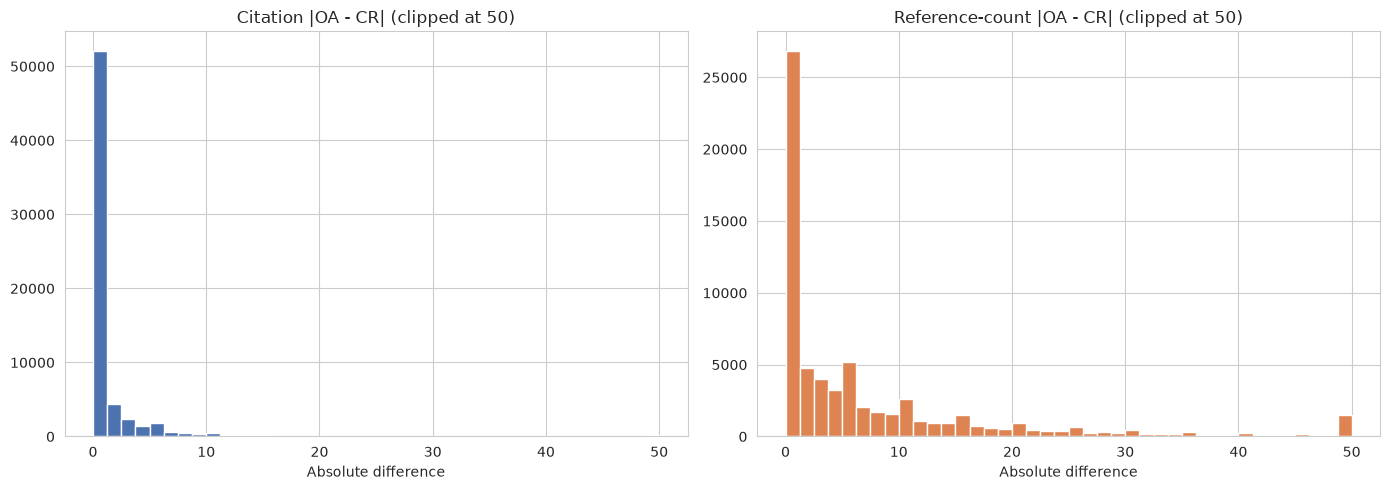

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(cite["abs_diff"].clip(upper=50), bins=40, color="#4C72B0")
axes[0].set_title("Citation |OA - CR| (clipped at 50)")
axes[0].set_xlabel("Absolute difference")

axes[1].hist(ref["abs_diff"].clip(upper=50), bins=40, color="#DD8452")
axes[1].set_title("Reference-count |OA - CR| (clipped at 50)")
axes[1].set_xlabel("Absolute difference")
plt.tight_layout()
plt.show()


## 10. Type-wise conflict rates (title / year / type / publisher)


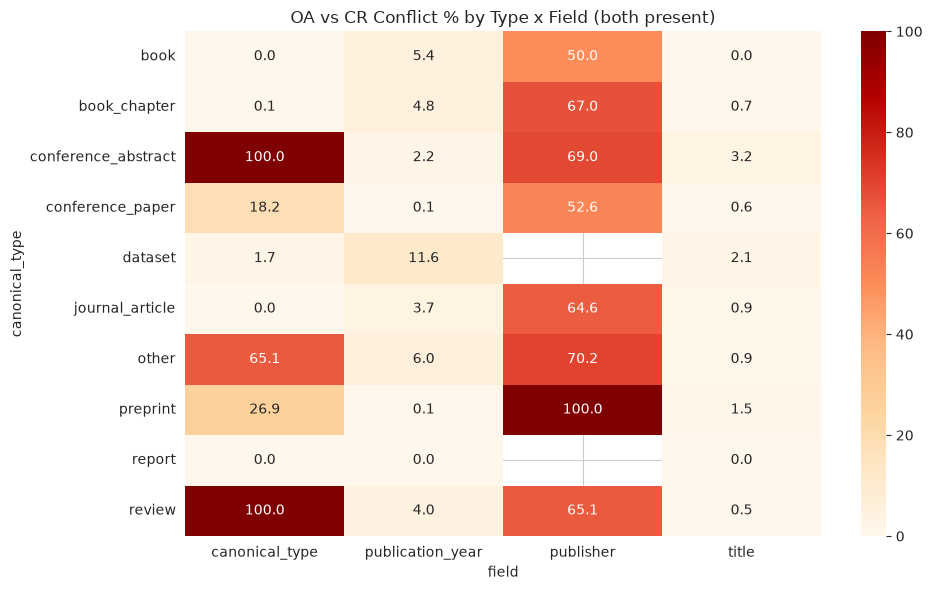

,canonical_type,records,field,both_present,conflict_pct_of_both
0,book,148,title,148,0.00
1,book,148,publisher,46,50.00
2,book,148,canonical_type,148,0.00
3,book,148,publication_year,148,5.41
4,book_chapter,2987,title,2987,0.70
5,book_chapter,2987,publisher,1433,66.99
6,book_chapter,2987,canonical_type,2987,0.10
7,book_chapter,2987,publication_year,2970,4.81
8,conference_abstract,1070,title,1070,3.18
9,conference_abstract,1070,publisher,348,68.97


In [11]:
def typewise_conflicts(df, type_col="canonical_type_oa"):
    rows = []
    for ctype, g in df.groupby(type_col):
        if len(g) < 50:
            continue
        for field, lcol, rcol, norm in [
            ("title", "title_oa", "title_cr", normalize_title),
            ("publisher", "publisher_oa", "publisher_cr", normalize_text),
            ("canonical_type", "canonical_type_oa", "canonical_type_cr", normalize_text),
        ]:
            if lcol not in g.columns or rcol not in g.columns:
                continue
            left_n = g[lcol].map(norm)
            right_n = g[rcol].map(norm)
            both = left_n.notna() & right_n.notna()
            if both.sum() == 0:
                continue
            conflict_pct = round(100 * ((left_n != right_n) & both).sum() / both.sum(), 2)
            rows.append({
                "canonical_type": ctype,
                "records": len(g),
                "field": field,
                "both_present": int(both.sum()),
                "conflict_pct_of_both": conflict_pct,
            })
        # year
        y_oa = pd.to_numeric(g["publication_year_oa"], errors="coerce")
        y_cr = pd.to_numeric(g["publication_year_cr"], errors="coerce")
        both = y_oa.notna() & y_cr.notna()
        if both.sum():
            rows.append({
                "canonical_type": ctype,
                "records": len(g),
                "field": "publication_year",
                "both_present": int(both.sum()),
                "conflict_pct_of_both": round(100 * ((y_oa != y_cr) & both).sum() / both.sum(), 2),
            })
    return pd.DataFrame(rows)


type_conflicts = typewise_conflicts(oa_cr)
type_conflicts.to_csv(OUTPUT_DIR / "conflicts_by_publication_type.csv", index=False)

if not type_conflicts.empty:
    mat = type_conflicts.pivot(
        index="canonical_type", columns="field", values="conflict_pct_of_both"
    )
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(mat, annot=True, fmt=".1f", cmap="OrRd", ax=ax)
    ax.set_title("OA vs CR Conflict % by Type x Field (both present)")
    plt.tight_layout()
    plt.show()

type_conflicts.head(30)


## 11. Resolution policy for conflicts


In [12]:
resolution_policy = pd.DataFrame([
    {"field": "title", "winner": "OpenAlex", "reason": "SoT; conflicts rare (~1% normalized)", "action": "keep_oa; log_conflict"},
    {"field": "publication_year", "winner": "OpenAlex", "reason": "SoT; ~3% disagree, <0.2% differ by >=2 yrs", "action": "keep_oa; log_if_abs_diff_ge_2"},
    {"field": "canonical_type", "winner": "OpenAlex", "reason": "normalize both; OA preferred for SL corpus", "action": "keep_oa_canonical; store_raw_both"},
    {"field": "publisher", "winner": "OpenAlex_if_present_else_Crossref", "reason": "exact string match low (~34%) due to naming variants", "action": "prefer_oa; fill_cr; do_not_flag_all_as_hard_conflict"},
    {"field": "journal", "winner": "OpenAlex_if_present_else_Crossref", "reason": "naming variants; fill venue gaps from CR", "action": "prefer_oa; enrich_cr_when_oa_missing"},
    {"field": "issn/volume/issue/page", "winner": "Crossref_when_oa_missing", "reason": "venue enrichment fields", "action": "fill_from_cr"},
    {"field": "citation_count", "winner": "keep_both", "reason": "different indexes; ~3.6% abs>=10", "action": "store_oa_and_cr; flag_divergence"},
    {"field": "reference_count", "winner": "keep_both", "reason": "counts often diverge", "action": "store_oa_and_cr; optional_flag"},
    {"field": "abstract", "winner": "Crossref_then_Local", "reason": "OA export has no abstract", "action": "fill_cr_then_local"},
    {"field": "keywords", "winner": "Local", "reason": "only Local provides keywords", "action": "fill_local"},
])
resolution_policy.to_csv(OUTPUT_DIR / "conflict_resolution_policy.csv", index=False)
resolution_policy


,field,winner,reason,action
0,title,OpenAlex,SoT; conflicts rare (~1% normalized),keep_oa; log_conflict
1,publication_year,OpenAlex,"SoT; ~3% disagree, <0.2% differ by >=2 yrs",keep_oa; log_if_abs_diff_ge_2
2,canonical_type,OpenAlex,normalize both; OA preferred for SL corpus,keep_oa_canonical; store_raw_both
3,publisher,OpenAlex_if_present_else_Crossref,exact string match low (~34%) due to naming va...,prefer_oa; fill_cr; do_not_flag_all_as_hard_co...
4,journal,OpenAlex_if_present_else_Crossref,naming variants; fill venue gaps from CR,prefer_oa; enrich_cr_when_oa_missing
5,issn/volume/issue/page,Crossref_when_oa_missing,venue enrichment fields,fill_from_cr
6,citation_count,keep_both,different indexes; ~3.6% abs>=10,store_oa_and_cr; flag_divergence
7,reference_count,keep_both,counts often diverge,store_oa_and_cr; optional_flag
8,abstract,Crossref_then_Local,OA export has no abstract,fill_cr_then_local
9,keywords,Local,only Local provides keywords,fill_local


## 12. Field-level data-quality scorecard

Combine:

- completeness from each source (notebook 02 style)
- conflict rate on common DOIs (this notebook)
- enrichment fill opportunity (notebook 03 style)

into a single DQ table per canonical field.


In [13]:
MISSING = MISSING_TOKENS


def present_rate(series):
    return round(100 * (~series.map(is_missing)).mean(), 2) if len(series) else 0.0


# Completeness on full corpora
FIELD_COMPLETENESS = {
    "doi": {
        "OpenAlex": present_rate(oa["doi"]),
        "Crossref": present_rate(cr["DOI"]),
        "Local": present_rate(local["doi"]),
    },
    "title": {
        "OpenAlex": present_rate(oa["title"]),
        "Crossref": present_rate(cr["title"]),
        "Local": present_rate(local["title"]),
    },
    "publication_year": {
        "OpenAlex": present_rate(oa["publication_year"]),
        "Crossref": present_rate(cr["publication_year"]),
        "Local": present_rate(local["publication_year"]),
    },
    "publication_type": {
        "OpenAlex": present_rate(oa["type"]),
        "Crossref": present_rate(cr["type"]),
        "Local": present_rate(local["publication_type"]),
    },
    "authors": {
        "OpenAlex": present_rate(oa["authors"]),
        "Crossref": present_rate(cr["author_name"]),
        "Local": present_rate(local["authors"]),
    },
    "publisher": {
        "OpenAlex": present_rate(oa["publisher"]),
        "Crossref": present_rate(cr["publisher"]),
        "Local": present_rate(local["publisher"]),
    },
    "journal": {
        "OpenAlex": present_rate(oa["source_name"]),
        "Crossref": present_rate(cr["container-title"]),
        "Local": present_rate(local["journal"]),
    },
    "abstract": {
        "OpenAlex": 0.0,
        "Crossref": present_rate(cr["abstract"]),
        "Local": present_rate(local["abstract"]),
    },
    "issn": {
        "OpenAlex": present_rate(oa["issn_l"]),
        "Crossref": present_rate(cr["ISSN"]),
        "Local": 0.0,
    },
    "volume": {
        "OpenAlex": present_rate(oa["volume"]),
        "Crossref": present_rate(cr["volume"]),
        "Local": 0.0,
    },
    "issue": {
        "OpenAlex": present_rate(oa["issue"]),
        "Crossref": present_rate(cr["issue"]),
        "Local": 0.0,
    },
    "citation_count": {
        "OpenAlex": present_rate(oa["cited_by_count"]),
        "Crossref": present_rate(cr["is-referenced-by-count"]),
        "Local": 0.0,
    },
    "reference_count": {
        "OpenAlex": present_rate(oa["referenced_works_count"]),
        "Crossref": present_rate(cr["reference-count"]),
        "Local": 0.0,
    },
    "license": {
        "OpenAlex": present_rate(oa["license"]),
        "Crossref": present_rate(cr["license_URL"]),
        "Local": present_rate(local["rights"]) if "rights" in local.columns else 0.0,
    },
    "keywords": {
        "OpenAlex": 0.0,
        "Crossref": 0.0,
        "Local": present_rate(local["keywords"]) if "keywords" in local.columns else 0.0,
    },
    "language": {
        "OpenAlex": present_rate(oa["language"]),
        "Crossref": present_rate(cr["language"]),
        "Local": present_rate(local["language"]) if "language" in local.columns else 0.0,
    },
}

# Conflict % lookup from OA-CR table
conflict_map = {
    r.field: r.conflict_pct_of_both
    for _, r in oa_cr_conflicts.iterrows()
}
conflict_map["citation_count"] = numeric_conflict_summary.loc[
    numeric_conflict_summary["metric"] == "citation_count", "pct_abs_diff_ge_10"
].iloc[0]
conflict_map["reference_count"] = numeric_conflict_summary.loc[
    numeric_conflict_summary["metric"] == "reference_count", "pct_abs_diff_ge_10"
].iloc[0]

# Enrichment fillable from notebook03 if available, else recompute rough
enrich_path = Path("./outputs/notebook03/enrichment_opportunity_matrix.csv")
fill_map = {}
if enrich_path.exists():
    em = pd.read_csv(enrich_path)
    fill_map = dict(zip(em["field"], em["fillable_pct_of_common"]))

PRIMARY = {
    "doi": "OpenAlex",
    "title": "OpenAlex",
    "publication_year": "OpenAlex",
    "publication_type": "OpenAlex",
    "authors": "OpenAlex",
    "publisher": "OpenAlex",
    "journal": "OpenAlex",
    "abstract": "Crossref",
    "issn": "Crossref",
    "volume": "Crossref",
    "issue": "Crossref",
    "citation_count": "OpenAlex",
    "reference_count": "keep_both",
    "license": "OpenAlex+Crossref",
    "keywords": "Local",
    "language": "OpenAlex",
}


def dq_score(completeness_primary, conflict_pct, fillable_pct):
    # Higher completeness good; higher conflict bad; fillable is opportunity not quality
    c = 0 if pd.isna(completeness_primary) else completeness_primary
    conf = 0 if pd.isna(conflict_pct) else conflict_pct
    # Score 0-100
    return round(max(0, min(100, c - 0.5 * conf)), 2)


rows = []
for field, comps in FIELD_COMPLETENESS.items():
    primary = PRIMARY.get(field, "OpenAlex")
    primary_comp = comps.get(
        "OpenAlex" if primary.startswith("OpenAlex") else (
            "Crossref" if "Crossref" in primary else "Local"
        ),
        comps["OpenAlex"],
    )
    if primary == "keep_both":
        primary_comp = comps["OpenAlex"]
    if primary == "Crossref":
        primary_comp = comps["Crossref"]
    if primary == "Local":
        primary_comp = comps["Local"]

    conf = conflict_map.get(field, np.nan)
    fill = fill_map.get(field, np.nan)
    # map journal/issn naming
    if pd.isna(fill):
        fill = fill_map.get({
            "journal": "journal",
            "issn": "issn",
            "volume": "volume",
            "issue": "issue",
            "abstract": "abstract",
            "license": "license",
            "citation_count": "citation_count",
            "reference_count": "reference_count",
        }.get(field, field), np.nan)

    rows.append({
        "canonical_field": field,
        "openalex_completeness_pct": comps["OpenAlex"],
        "crossref_completeness_pct": comps["Crossref"],
        "local_completeness_pct": comps["Local"],
        "preferred_source": primary,
        "conflict_pct_oa_vs_cr": conf,
        "enrichment_fillable_pct_common_dois": fill,
        "dq_score": dq_score(primary_comp, conf if not pd.isna(conf) else 0, fill),
        "quality_band": (
            "Excellent" if dq_score(primary_comp, conf if not pd.isna(conf) else 0, fill) >= 90
            else "Good" if dq_score(primary_comp, conf if not pd.isna(conf) else 0, fill) >= 70
            else "Fair" if dq_score(primary_comp, conf if not pd.isna(conf) else 0, fill) >= 40
            else "Poor"
        ),
    })

dq_scorecard = pd.DataFrame(rows).sort_values("dq_score", ascending=False)
dq_scorecard.to_csv(OUTPUT_DIR / "field_level_data_quality_scorecard.csv", index=False)
dq_scorecard


,canonical_field,openalex_completeness_pct,crossref_completeness_pct,local_completeness_pct,preferred_source,conflict_pct_oa_vs_cr,enrichment_fillable_pct_common_dois,dq_score,quality_band
3,publication_type,100.00,100.00,99.19,OpenAlex,NaN,NaN,100.00,Excellent
4,authors,100.00,60.06,98.21,OpenAlex,NaN,NaN,100.00,Excellent
1,title,99.88,99.87,99.99,OpenAlex,0.90,NaN,99.43,Excellent
2,publication_year,100.00,99.75,100.00,OpenAlex,2.96,NaN,98.52,Excellent
11,citation_count,100.00,100.00,0.00,OpenAlex,3.59,0.00,98.20,Excellent
0,doi,97.42,100.00,41.78,OpenAlex,NaN,NaN,97.42,Excellent
15,language,91.35,47.70,66.49,OpenAlex,0.61,NaN,91.04,Excellent
12,reference_count,100.00,100.00,0.00,keep_both,25.10,0.00,87.45,Good
9,volume,65.66,67.81,0.00,Crossref,0.02,0.05,67.80,Fair
14,keywords,0.00,0.00,64.78,Local,NaN,NaN,64.78,Fair


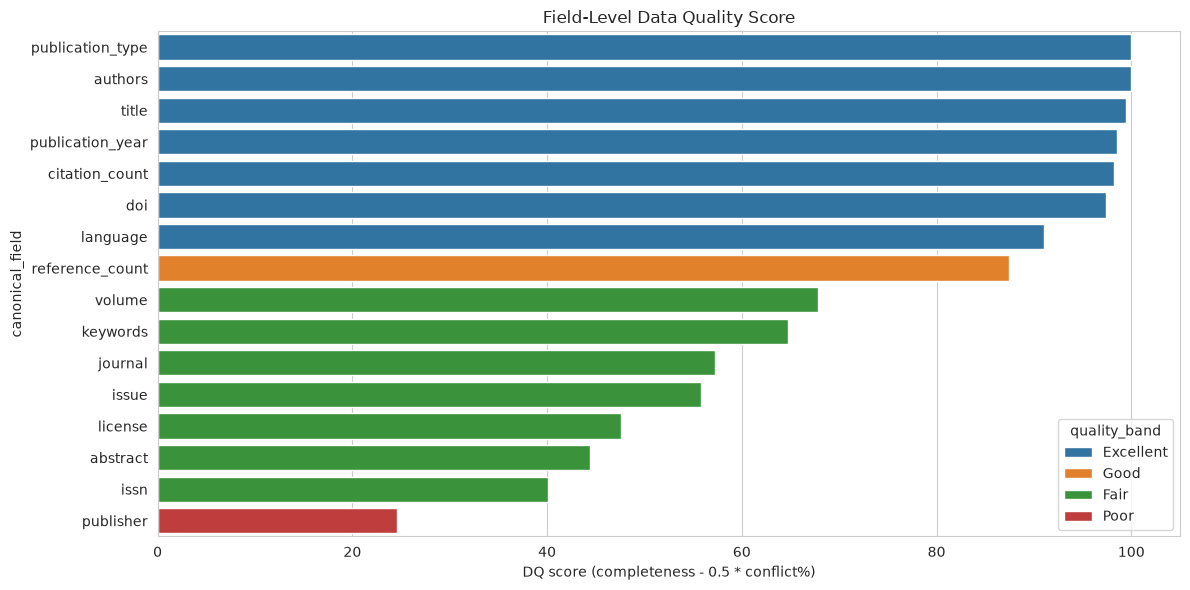

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=dq_scorecard, x="dq_score", y="canonical_field", hue="quality_band", dodge=False, ax=ax)
ax.set_title("Field-Level Data Quality Score")
ax.set_xlabel("DQ score (completeness - 0.5 * conflict%)")
plt.tight_layout()
plt.show()


## 13. Combined conflict + DQ export for the report


In [15]:
all_conflicts = pd.concat([
    oa_cr_conflicts.assign(comparison="OpenAlex_vs_Crossref"),
    oa_local_conflicts.assign(comparison="OpenAlex_vs_Local"),
], ignore_index=True, sort=False)
all_conflicts.to_csv(OUTPUT_DIR / "all_conflicts_summary.csv", index=False)

summary = {
    "oa_cr_common_dois": len(oa_cr),
    "oa_local_common_dois": len(oa_local),
    "title_conflict_pct_oa_cr": float(
        oa_cr_conflicts.loc[oa_cr_conflicts["field"] == "title", "conflict_pct_of_both"].iloc[0]
    ),
    "year_conflict_pct_oa_cr": float(
        oa_cr_conflicts.loc[oa_cr_conflicts["field"] == "publication_year", "conflict_pct_of_both"].iloc[0]
    ),
    "publisher_conflict_pct_oa_cr": float(
        oa_cr_conflicts.loc[oa_cr_conflicts["field"] == "publisher", "conflict_pct_of_both"].iloc[0]
    ),
    "citation_pct_abs_diff_ge_10": float(
        numeric_conflict_summary.loc[
            numeric_conflict_summary["metric"] == "citation_count", "pct_abs_diff_ge_10"
        ].iloc[0]
    ),
    "fields_excellent_dq": int((dq_scorecard["quality_band"] == "Excellent").sum()),
    "fields_poor_dq": int((dq_scorecard["quality_band"] == "Poor").sum()),
}
pd.Series(summary).to_csv(OUTPUT_DIR / "notebook04_executive_summary.csv", header=["value"])
print(pd.Series(summary))


oa_cr_common_dois               65891.00
oa_local_common_dois            13710.00
title_conflict_pct_oa_cr            0.90
year_conflict_pct_oa_cr             2.96
publisher_conflict_pct_oa_cr       66.25
citation_pct_abs_diff_ge_10         3.59
fields_excellent_dq                 7.00
fields_poor_dq                      1.00
dtype: float64


## 14. Key takeaways

1. **Titles / years** rarely conflict between OpenAlex and Crossref on common DOIs — safe to treat OA as SoT.
2. **Publisher / journal** string conflicts are common because of naming variants, not true bibliographic disagreement — prefer OA, fill gaps from CR, avoid hard-conflict flags for exact-string mismatch alone.
3. **Citations / references** should be stored from both sources with a divergence flag.
4. **Abstracts / keywords / ORCID / funding / events** are completeness problems more than conflict problems — fill from Crossref/Local.
5. Use the **field-level DQ scorecard** as the report table for data-quality statistics.
